# 06 Three-Way Qualitative Comparison

**Pure Faster R-CNN** vs **Neuro-Symbolic (Faster R-CNN + SODT)** vs **Grad-CAM**

This notebook randomly picks **N** images from the DeepPCB *test* split and feeds each through three pipelines:

| Column | Pipeline | Explanation |
|--------|----------|-------------|
| 1 | **Pure Faster R-CNN** | Detection boxes + class scores only |
| 2 | **Neuro-Symbolic** (Faster R-CNN + SODT) | Detection + SODT evidence heatmaps + tree path |
| 3 | **Grad-CAM** | Detection + backbone saliency heatmap |

Goal: qualitatively demonstrate that the SODT's intrinsic explanations
align with Grad-CAM's gradient-based saliency, thereby validating the
faithfulness of the symbolic explanations.

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.inference import load_checkpoint_model
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from neurosym.inference import (
    load_neurosymbolic_detector,
    run_neurosymbolic_inference,
    explain_hybrid_detections,
    select_detection_indices,
)
from neurosym.visualization import (
    image_to_array,
    heatmap_to_array,
    draw_numbered_detections,
    draw_neurosymbolic_explanation,
    zoom_axis_to_box,
)
from gradcam.gradcam import GradCAM
from util.config import load_yaml
from util.device import select_device

PROJECT_ROOT = resolve_root()

## 1. Load Models

In [2]:
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)

device = select_device(train_config["device"])
detector_ckpt = PROJECT_ROOT / "checkpoints" / "neuro" / "BESTEST.pt"
symbolic_ckpt = PROJECT_ROOT / "checkpoints" / "symbolic" / "BESTEST.pt"

class_names = tuple(train_config["dataset"]["class_names"])
preprocess = test_preprocess()

# --- Pure Faster R-CNN ---
frcnn_model, _ = load_checkpoint_model(
    detector_ckpt,
    model_config_path=Path("neuro.yaml"),
    train_config_path=Path("neuro_train.yaml"),
    device=str(device),
)
print("✓ Pure Faster R-CNN loaded")

# --- Neuro-Symbolic (SODT) ---
hybrid_model, _ = load_neurosymbolic_detector(
    detector_checkpoint_path=detector_ckpt,
    neuro_config=neuro_config,
    train_config=train_config,
    symbolic_checkpoint_path=symbolic_ckpt,
    device=str(device),
)
print("✓ Neuro-Symbolic (Faster R-CNN + SODT) loaded")

# --- Grad-CAM ---
gradcam = GradCAM(frcnn_model, device=str(device))
print("✓ Grad-CAM initialised (hooked into layer4/c5)")

✓ Pure Faster R-CNN loaded
✓ Neuro-Symbolic (Faster R-CNN + SODT) loaded
✓ Grad-CAM initialised (hooked into layer4/c5)


## 2. Sample Test Images

In [3]:
test_dataset = PCBDataset(train_config, split_file="test.txt")
test_dataset.add_preprocess(preprocess)

N = 4  # Number of test images to compare
random.seed(42)
sample_indices = random.sample(range(len(test_dataset)), k=min(N, len(test_dataset)))

print(f"Test set size : {len(test_dataset)}")
print(f"Selected indices: {sample_indices}")

Test set size : 500
Selected indices: [327, 57, 12, 379]


## 3. Three-Way Column Comparison

For each selected test image we show:
1. **All Detections**: A 3-column figure showing all detections for Faster R-CNN, SODT, and Grad-CAM.
2. **Interactive Explanation**: An interactive widget to select a specific detection and view its side-by-side explanation (Pruned SODT Tree vs Grad-CAM heatmap).


Test Image #327



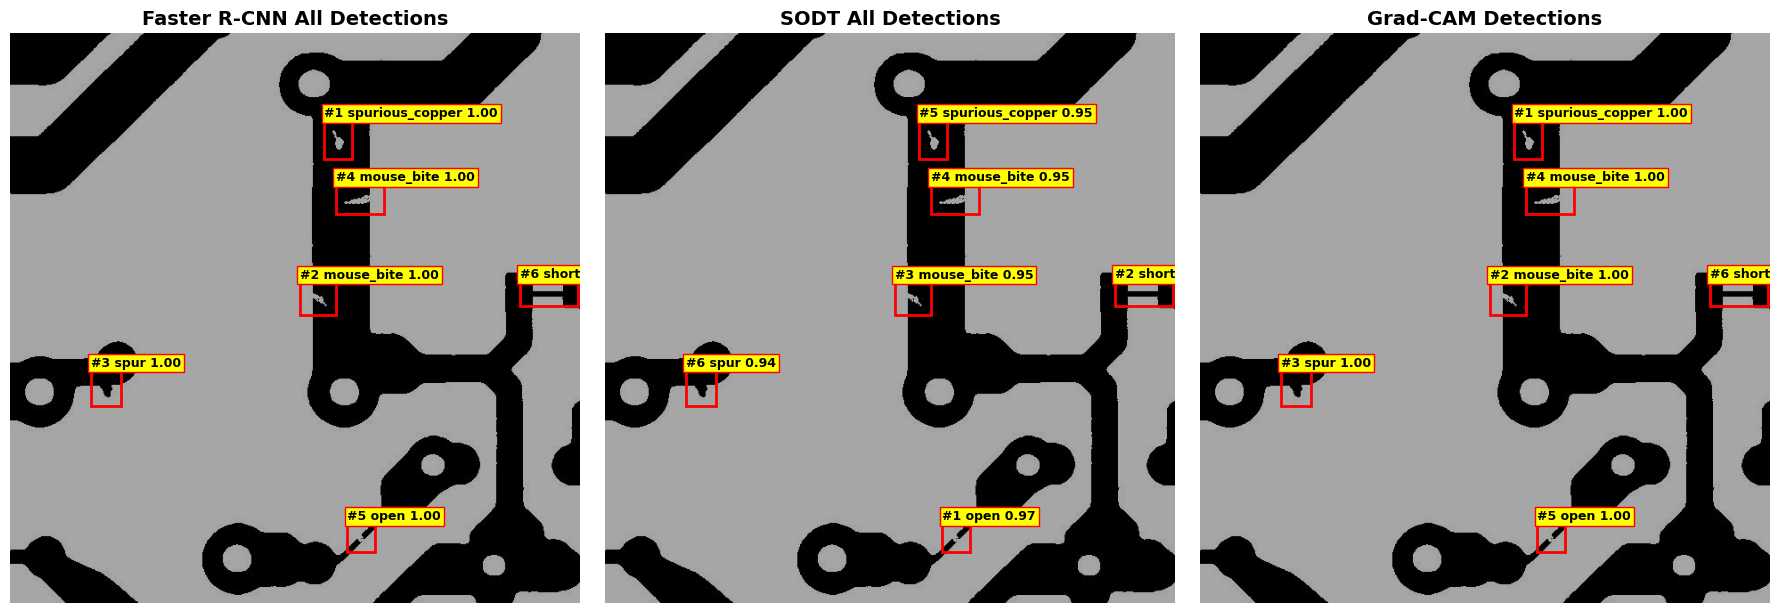

Output()


Test Image #57



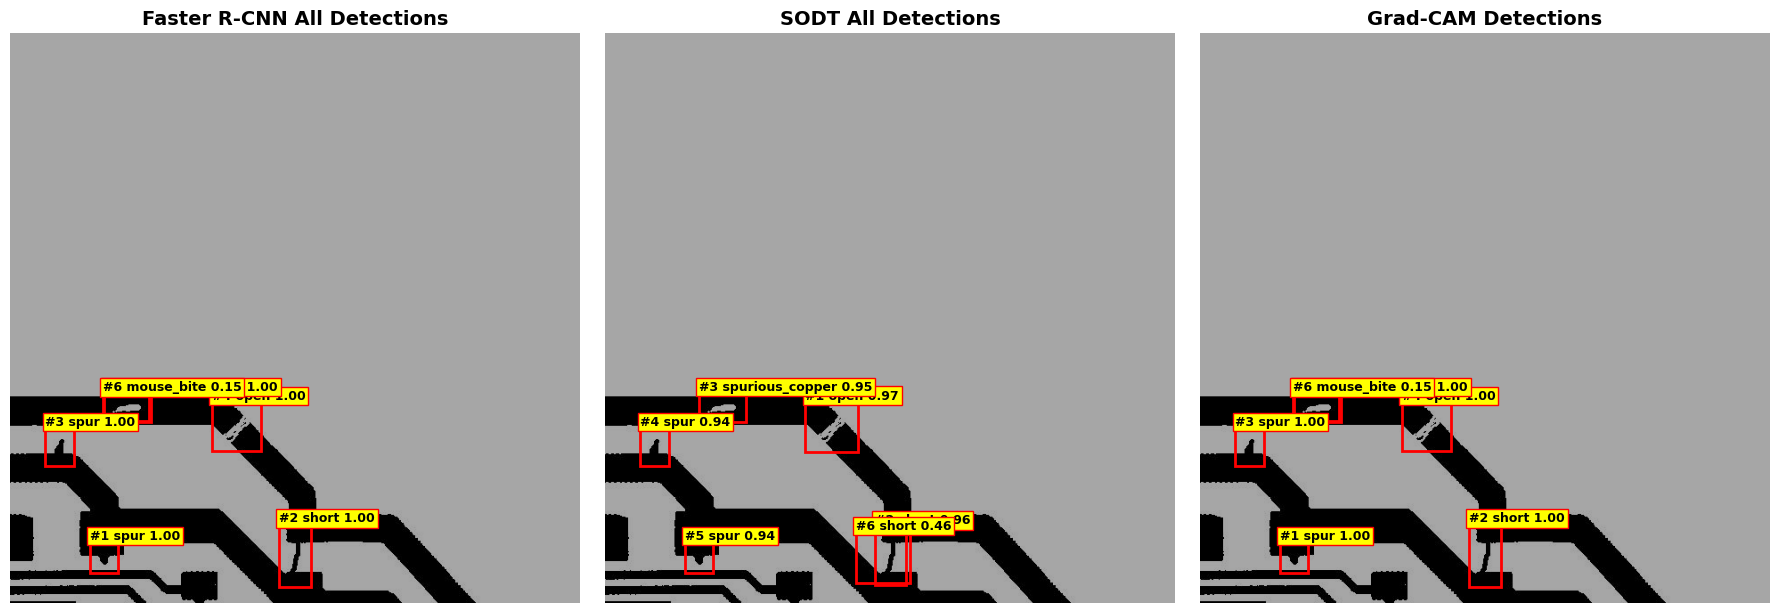

Output()


Test Image #12



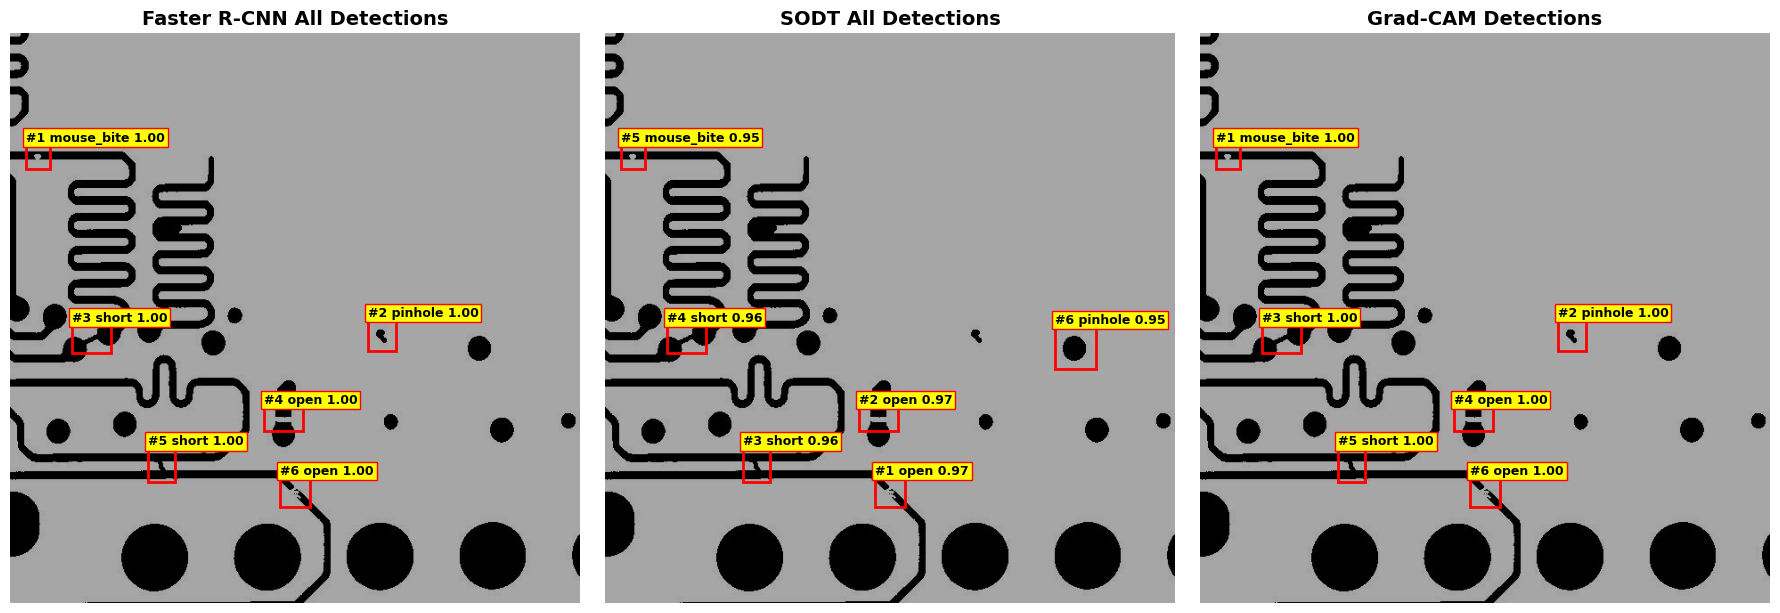

Output()


Test Image #379



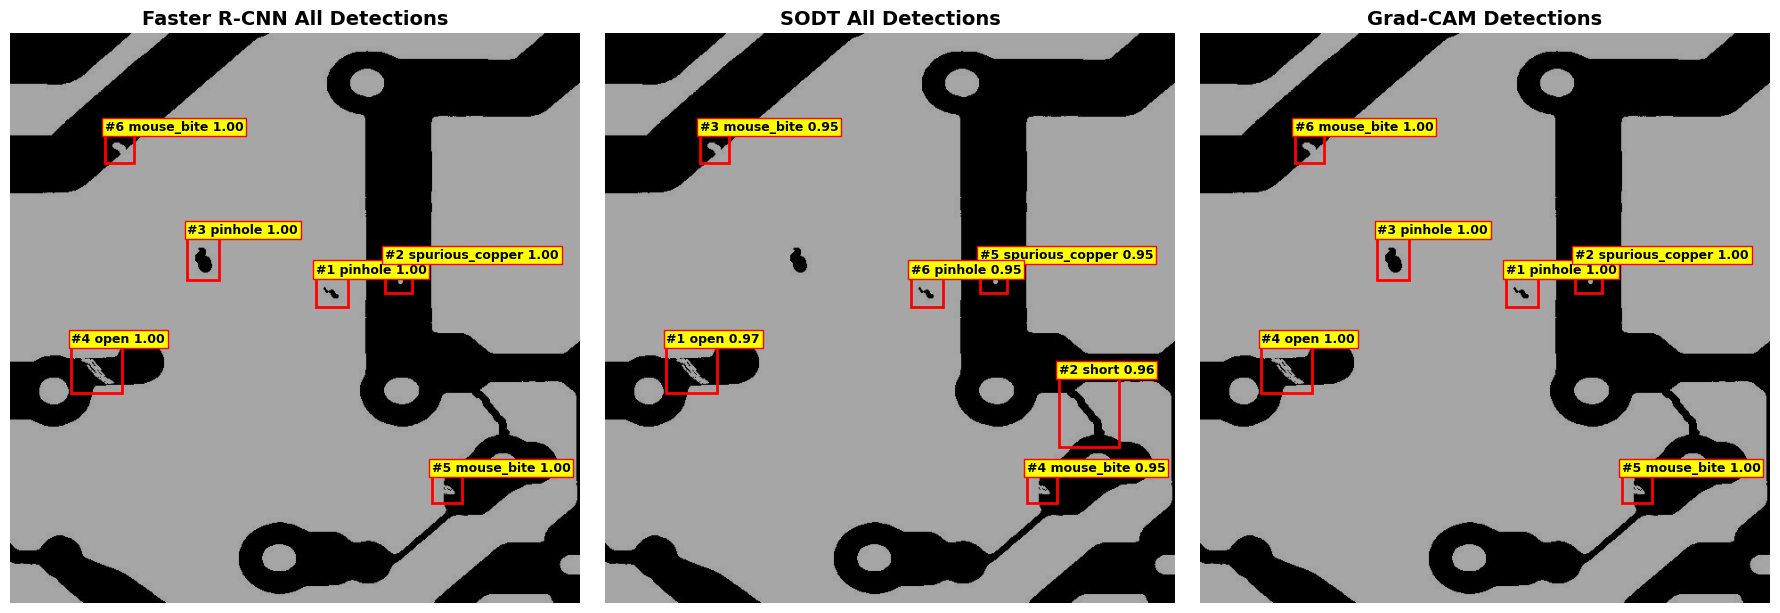

Output()

In [4]:
SCORE_THRESHOLD = 0.3
MAX_DETECTIONS = 6


def _draw_gradcam_panel_in_axis(ax, image_tensor, gcam_result, class_names):
    from neurosym.heatmap import project_heatmap_to_image

    img = image_to_array(image_tensor)
    ax.imshow(img)

    dimmer = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.float32)
    dimmer[..., 3] = 0.4
    ax.imshow(dimmer)

    heatmap_tensor = gcam_result["heatmap"]
    box = gcam_result["box"]
    image_shape = tuple(image_tensor.shape[-2:])

    projected = project_heatmap_to_image(heatmap_tensor, box, image_shape)

    rgba = heatmap_to_array(projected)
    ax.imshow(rgba)

    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="cyan",
            facecolor="none",
        )
    )

    zoom_axis_to_box(ax, box, image_shape)
    label = gcam_result["label"]
    score = gcam_result["score"]
    name = class_names[label - 1] if 0 < label <= len(class_names) else f"cls{label}"
    ax.set_title(
        f"Grad-CAM Focus\n{name} {score:.2f}",
        fontsize=10,
        fontweight="bold",
        color="#c62828",
    )
    ax.axis("off")


for sample_idx in sample_indices:
    image_tensor, target = test_dataset[sample_idx]
    image_shape = tuple(image_tensor.shape[-2:])

    # ---------- (A) Pure Faster R-CNN inference ----------
    with torch.inference_mode():
        frcnn_preds = frcnn_model([image_tensor.to(device)])
        frcnn_det = {k: v.detach().cpu() for k, v in frcnn_preds[0].items()}

    # ---------- (B) Neuro-Symbolic inference + explanation ----------
    with torch.inference_mode():
        hybrid_preds = run_neurosymbolic_inference(
            hybrid_model, [image_tensor.to(device)]
        )
        hybrid_det = hybrid_preds[0]

    sodt_indices = select_detection_indices(
        hybrid_det,
        score_threshold=SCORE_THRESHOLD,
        max_detections=MAX_DETECTIONS,
    )

    sodt_explanations = explain_hybrid_detections(
        hybrid_model,
        hybrid_det,
        image_shape=image_shape,
        detection_indices=sodt_indices,
        mode="local_instance_evidence_map",
    )

    # ---------- (C) Grad-CAM ----------
    boxes_selected = hybrid_det["boxes"][sodt_indices]
    labels_selected = hybrid_det["labels"][sodt_indices]
    scores_selected = hybrid_det["scores"][sodt_indices]

    if len(sodt_indices) > 0:
        gcam_heatmaps = gradcam.generate(
            image_tensor,
            boxes_selected.to(device),
            labels_selected.to(device),
            output_size=(7, 7),
        )
        gcam_results = [
            {
                "box": boxes_selected[i].detach().cpu(),
                "label": int(labels_selected[i]),
                "score": float(scores_selected[i]),
                "heatmap": gcam_heatmaps[i],
            }
            for i in range(len(sodt_indices))
        ]
    else:
        gcam_results = []

    print(f"\n{'=' * 100}")
    print(f"Test Image #{sample_idx}")
    print(f"{'=' * 100}\n")

    # === 1. Top Section: 3-column ALL detections ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    draw_numbered_detections(
        axes[0], image_tensor, frcnn_det, sodt_indices, class_names
    )
    axes[0].set_title("Faster R-CNN All Detections", fontsize=14, fontweight="bold")

    draw_numbered_detections(
        axes[1], image_tensor, hybrid_det, sodt_indices, class_names
    )
    axes[1].set_title("SODT All Detections", fontsize=14, fontweight="bold")

    draw_numbered_detections(
        axes[2], image_tensor, frcnn_det, sodt_indices, class_names
    )
    axes[2].set_title("Grad-CAM Detections", fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

    # === 2. Interactive Explanations ===
    if len(sodt_indices) == 0:
        print("No detections above threshold.")
        continue

    out = widgets.Output()

    def make_btn(
        btn_num, det_idx, expl, gcam_res, tnsr=image_tensor, hyb=hybrid_det, out_w=out
    ):
        label_name = class_names[expl["label"] - 1]
        score = expl["score"]
        btn = widgets.Button(
            description=f"#{btn_num} {label_name} {score:.2f}",
            layout=widgets.Layout(width="180px"),
        )

        def on_click(_):
            with out_w:
                clear_output(wait=True)

                def gcam_panel(ax):
                    _draw_gradcam_panel_in_axis(ax, tnsr, gcam_res, class_names)

                draw_neurosymbolic_explanation(
                    tnsr,
                    hyb,
                    det_idx,
                    expl,
                    class_names,
                    hybrid_model.symbolic_tree,
                    selected_number=btn_num,
                    extra_panel_func=gcam_panel,
                )

        btn.on_click(on_click)
        return btn

    buttons = []
    for btn_num, (det_idx, expl, gcam_res) in enumerate(
        zip(sodt_indices, sodt_explanations, gcam_results), 1
    ):
        buttons.append(make_btn(btn_num, det_idx, expl, gcam_res))

    display(widgets.HBox(buttons))
    display(out)

## 4. Cleanup

In [5]:
gradcam.release()
print("Grad-CAM hooks released.")

Grad-CAM hooks released.
